## Process SFNO and ERA5 data for Storm Desmond (December 2015) to compare distribution of precipitation

- Read in datasets and process the input files 
- Produce simple plots of ERA5
- Identify the SFNO forecasts that are most similar to ERA5 around the time of the event (5-6 December 2015)
- Calculate the distribution of mslp and precip in these forecasts and compare with ERA5 
- Use the differences in these distributions to calculate a scale factor that we can apply to address the issue of low precip

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import math
import regionmask
sns.set_theme()
import logging
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import os
import re
import pandas as pd
import matplotlib.dates as mdates
import metpy.plots.ctables as mp
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from statsmodels.distributions.empirical_distribution import ECDF

import plotting_functions as pf

## Load metadata from the config file

- `file_path`, `date_str`, `event_name`

In [2]:
config_file_path = '/mnt/data/data_analysis/config.json'
events = pf.load_config(config_file_path)
event_str = 'Desmond' # ['21Aug2015', '22Aug2015', 'Charley_20Aug1986', 'Desmond', 'Desmond_seed76', 'event_response'] 
file_path = events[event_str]['path']
files = sorted(glob.glob(f'{file_path}/*.nc'))
date_str = events[event_str]['date_str']
event_name = events[event_str]['name']

## Pre-process the ERA5 data to calculate 24-h accumulated precipitation

In [ ]:
# repeat for precip data
era5_prcp_path = '/mnt/data/era5/era5_precip_041215_061215.grib'
era5_ds_pr = xr.open_dataset(era5_prcp_path,engine='cfgrib')


def extract_lat_lon_arrays(ds: xr.Dataset) -> tuple:
    """ 
    Extract latitude and longitude arrays from an xr.Dataset and return them as 1D arrays.
    """
    try:
        lon = ds['lon'].values
    except Exception: 
        lon = ds['longitude'].values

    try:
        lat = ds['lat'].values
    except Exception:
        lat = ds['latitude'].values

    return lat, lon


def preprocess_era5_grib(ds: xr.Dataset) -> xr.Dataset:
    """
    Preprocess ERA5 grib dataset to extract hourly precipitation and resample to 24h sums.
    """
    # Remove unnecessary dimensions and variables
    ds = ds.drop_vars([var for var in ds.data_vars if var not in ['tp']])
    
    # Ensure longitude is in the range [-180, 180]
    ds = pf.normalise_longitude(ds, lon_name='longitude')

    da = ds['tp']
    # convert units if needed (ERA5 often in metres -> mm)
    if 'units' in da.attrs and 'm' in da.attrs['units'].lower():
        da = da * 1000.0
        da.attrs['units'] = 'mm'

    if 'valid_time' in ds.coords:
        valid_time_2d = ds['valid_time'].values
    else:
        # step may be timedelta64 or strings like '01:00:00'
        time_vals = ds['time'].values     # shape (time,)
        step_vals = ds['step'].values     # shape (step,)
        # If step is timedelta64, addition works; otherwise try to convert step to timedeltas
        if np.issubdtype(step_vals.dtype, np.timedelta64):
            valid_time_2d = time_vals[:, None] + step_vals[None, :]
        else:
            # try interpreting step as "HH:MM:SS" strings or integers hours
            try:
                step_td = np.array([np.timedelta64(int(str(s).split(':')[0]), 'h') if ':' in str(s) else np.timedelta64(int(s), 'h')
                                    for s in step_vals])
                valid_time_2d = time_vals[:, None] + step_td[None, :]
            except Exception:
                raise RuntimeError("Couldn't interpret ds.step; inspect ds.step.dtype and values")

    n_time, n_step = valid_time_2d.shape

    lat, lon = extract_lat_lon_arrays(ds)

    era5_pr_flat = da.values.reshape(n_time * n_step, len(lat), len(lon)) # reshape from 4D to 3D (combine 'time' and 'step' dims)
    valid_time_flat = valid_time_2d.ravel() # turn from 2D into 1D 

    # build a DataArray indexed by 'valid_time'

    era5_pr_hourly = xr.DataArray(
        era5_pr_flat,
        coords={'valid_time': ('valid_time', valid_time_flat),
                'latitude': ('latitude', lat),
                'longitude': ('longitude', lon)},
        dims=('valid_time', 'latitude', 'longitude'),
        attrs=da.attrs
    )

    era5_pr_hourly = era5_pr_hourly.sortby('valid_time')
    era5_pr_hourly = era5_pr_hourly.groupby('valid_time').mean(dim='valid_time')

    # resample to 24h sums aligned to right edge (so windows end at 00:00)
    # label='right' and closed='right' makes the interval (t-24h, t] and labels it with t (the right edge).
    era5_tp24 = era5_pr_hourly.resample(valid_time='24h', label='right', closed='right').sum()
    
    return era5_tp24

era5_tp24 = preprocess_era5_grib(era5_ds_pr)

Ignoring index file '/mnt/data/era5/era5_precip_041215_061215.grib.5b7b6.idx' older than GRIB file


## Produce a plot of mslp and 24-h accumulated precip from ERA5

Ignoring index file '/mnt/data/era5/era5_041215_061215.grib.5b7b6.idx' older than GRIB file


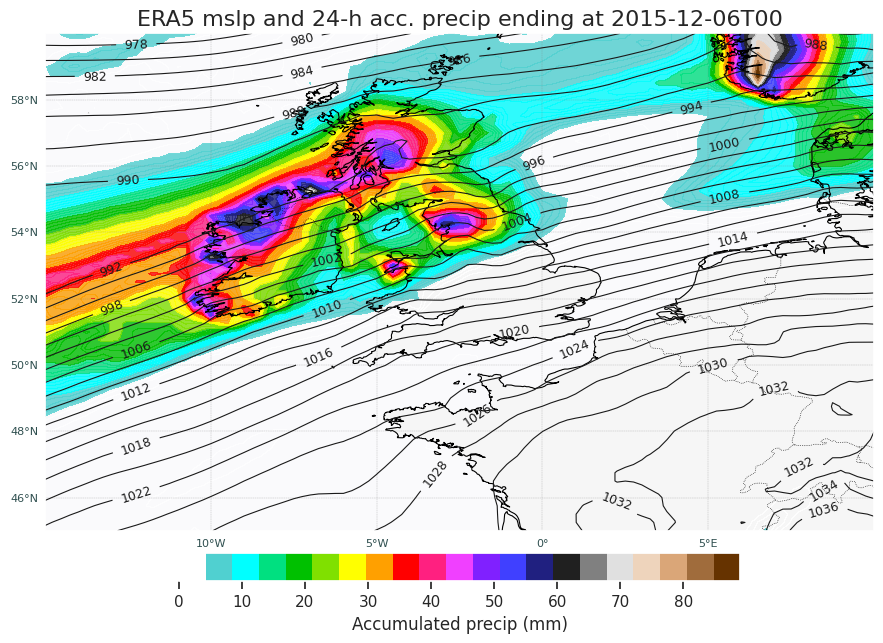

In [ ]:
crs = ccrs.PlateCarree()
cmap = pf.get_metpy_colourmap('precipitation')   # or another name from MetPy colortables

event_date_str = '2015-12-05T12'
event_date_sub = event_date_str.split(':')[0]
prcp_date_str = '2015-12-06T00'

# read in data from selected ensemble member and remove singleton dimension
era5_path = '/mnt/data/era5/era5_041215_061215.grib'
era5_ds = xr.open_dataset(era5_path,engine='cfgrib')
era5_ds = pf.normalise_longitude(era5_ds, lon_name='longitude')
era5_msl = era5_ds['msl'].sel(time=event_date_str)

# read in processed 24-h precip data (ending at 00Z on 6 December, i.e. 5 December)
era5_tp24 = era5_tp24.sel(valid_time=prcp_date_str)

# create 2D lat + lon arrays
lat, lon = extract_lat_lon_arrays(era5_ds) 
Lon, Lat = np.meshgrid(lon, lat)

# common function to add coastal features
def decorate(ax):
    #ax.set_extent(extent, crs=crs)
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', zorder=0)


# create a 'panel' plot with a single panel
fig, axes = plt.subplots(figsize=(9, 6),
                         subplot_kw={'projection': crs})

# Mean sea level pressure (pmsl)
ax = axes
decorate(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
# remove lat-lon labels on top and right axes 
try:
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
except AttributeError:
    gl.xlabels_top = False
    gl.xlabels_bottom = True
    gl.ylabels_left = False
    gl.ylabels_right = True

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# make the lat/lon labels smaller and lighter
gl.xlabel_style = {'size': 8, 'color': 'darkslategray'}
gl.ylabel_style = {'size': 8, 'color': 'darkslategray'}

# Convert MSLP to hPa if it's in Pa (common). Check units attribute if available.
era5_pr_np = era5_tp24.values.copy()
units = era5_msl.attrs.get('units', '').lower()
if 'pa' in units or (era5_msl.mean() > 2000):   # heuristic: values >> 1000 probably Pa
    era5_msl = era5_msl / 100.0
else:
    era5_msl = era5_msl
era5_msl_np = era5_msl.values.copy()

# make sensible contour levels (e.g. every 2 hPa)
p_min = np.nanmin(era5_msl_np)
p_max = np.nanmax(era5_msl_np)
interval = 2.0
levels = np.arange(np.floor(p_min / interval) * interval, np.ceil(p_max / interval) * interval + 1e-6, interval)

# repeat for precip
pr_min = np.nanmin(era5_pr_np)
pr_max = np.nanmax(era5_pr_np)
interval = 1.0
lev_min = np.floor(pr_min / interval)
lev_max = np.ceil(pr_max / interval)
pr_levels = np.arange(lev_min * interval, lev_max * interval + 1e-6, interval)

# add contour lines (isobars)
cs = ax.contour(Lon, Lat, era5_msl_np, levels=levels, colors='k', linewidths=0.8, transform=crs)
ax.clabel(cs, inline=True, fmt='%d', fontsize=9)
ax.set_title(f'ERA5 mslp and 24-h acc. precip ending at {prcp_date_str}',fontsize=16)

# also filled contour plot for precip
cs_pr = ax.contourf(Lon, Lat, era5_pr_np, levels=pr_levels, cmap=cmap, alpha=0.8, transform=crs)
plt.tight_layout()

# add and customise colourbar 
norm = mcolors.Normalize(vmin=lev_min, vmax=lev_max)
sm = ScalarMappable(norm=norm, cmap=cmap)  # only used for colorbar scaling if you want
sm.set_array([])
# place colorbar below the whole figure
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
cbar.set_label('Accumulated precip (mm)')
plt.show()

#out_file = f'/mnt/data/output_plots/{event_str}_{event_date_sub}_ERA5_mslp_24h_prcp.png'
#plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)

## Process the SFNO data to prepare for postage stamp plot

In [23]:
def calculate_rolling_total(ds: xr.Dataset | xr.DataArray, 
                            rolling_window: int,
                            min_periods: int,
                            lead_dim: str = 'valid_time') -> xr.DataArray:
    """ 
    Calculate a rolling sum over a given time dimension for a dataset.
    """

    if rolling_window is not None:
        if lead_dim is None:
            raise ValueError("Cannot compute rolling window without a lead/time dimension.")
        # rolling produces same-length lead dimension with NaNs in first (rolling_window-1) positions
        da_roll = ds.rolling({lead_dim: rolling_window}, min_periods=min_periods).sum()
    else:
        # assume da_s already is 24h totals with a lead_dim
        da_roll = ds
    return da_roll


def select_subset_by_bbox(ds: xr.Dataset, 
                          bbox=[-12.0, 2.5, 48.0, 60.0]):
    """ 
    Select a subset of the dataset based on a bounding box (lon0, lon1, lat0, lat1). This is useful for focusing on a specific region (e.g. UK and Ireland) and speeding up processing and plotting.
    """
    # Determine latitude and longitude coord names
    if 'latitude' in ds.coords:
        lat_name = 'latitude'
    elif 'lat' in ds.coords:
        lat_name = 'lat'
    else:
        raise ValueError("No latitude coordinate found (expected 'lat' or 'latitude').")

    if 'longitude' in ds.coords:
        lon_name = 'longitude'
    elif 'lon' in ds.coords:
        lon_name = 'lon'
    else:
        raise ValueError("No longitude coordinate found (expected 'lon' or 'longitude').")

    # Ensure latitudes are ordered from south -> north (ascending)
    ds = ds.sortby(lat_name)

    # latitude and longitude bounds for UK and Ireland region (lon0, lon1, lat0, lat1)
    lon0, lon1, lat0, lat1 = bbox
    ds = ds.sel({lat_name:slice(lat0,lat1), lon_name:slice(lon0,lon1)})

    return ds, lat_name, lon_name

In [34]:
crs = ccrs.PlateCarree()

# ----- parameters -----
panel_size = 1.3   # inches per small panel (changed from 5.2)
ncols = 10        # desired columns; adjust to taste (change to 8: 16 rows for 128 elements)
coast_res = '50m'  # '110m' (faster), '50m' (default), '10m' (slower)
show_location_dot = True
loc_lon, loc_lat = -6.26, 53.35   # example: Dublin (change or set to None)

# forecast lead time (initialised at 00Z on 23 November 2015)
best_lead = 324 # 132, 144, 144

# read in data using xarray 
datasets = []
seeds = []
for f in files:
    seed = pf.extract_seed(f)
    ds = xr.open_dataset(f).squeeze('time')
    ds, lat_name, lon_name = select_subset_by_bbox(ds)  # subset to region of interest and get lat/lon coord names
    datasets.append(ds)
    seeds.append(seed)

ds_all = xr.concat(datasets, dim=pd.Index(seeds, name='seed'))
ds_all = pf.normalise_longitude(ds_all, lon_name=lon_name)

# ds_lead dims expected: ensemble, lat, lon
da_mslp_all = ds_all.stack(member=('seed','ensemble'))['msl']  # DataArray: (ensemble, lat, lon)
da_pr_all = ds_all.stack(member=('seed','ensemble'))['tp06']
# convert from Pa to hPa
da_mslp_all = da_mslp_all / 100.0
# change units of 6-h acc precip from 'm' to 'mm'
da_pr_all = da_pr_all * 1000.0

# calculate rolling 24-h accumulated precip (try to use rolling window if possible, otherwise fall back to summing selected lead times)
rolling_window = 4
min_periods = 4
da_pr_roll = calculate_rolling_total(da_pr_all, rolling_window=rolling_window, min_periods=min_periods, lead_dim='lead_time')

# select requested lead_time as you did before (try label then fallback to isel)
best_lead = best_lead  # keep your variable

# select one lead time for mslp 
da_mslp_all = da_mslp_all.sel(lead_time=best_lead)
da_pr_roll = da_pr_roll.sel(lead_time=best_lead)

# TODO: tidy the commented code below 
# # calculate 24-h accumulated precip 
# da_pr_24 = da_pr_all.sel(lead_time=slice(best_lead,best_lead+23)).sum(dim='lead_time')
# try:
#     da_pr_06 = da_pr_all.sel(lead_time=best_lead)
# except Exception:
#     da_pr_06 = da_pr_all.isel(lead_time=int(best_lead))

# get readable labels using the 'seed' and 'ensemble' information from the index that we've created 
sample_index = da_mslp_all['member'].to_index()  # Index of (time, ensemble) tuples
labels = [f"seed: {t}, ens: {e}" for (t, e) in sample_index]

## Produce a `postage stamp` plot of all ensemble members 

- Either mean sea level pressure (`mslp`) or 6-h accumulated precip (`pr`)

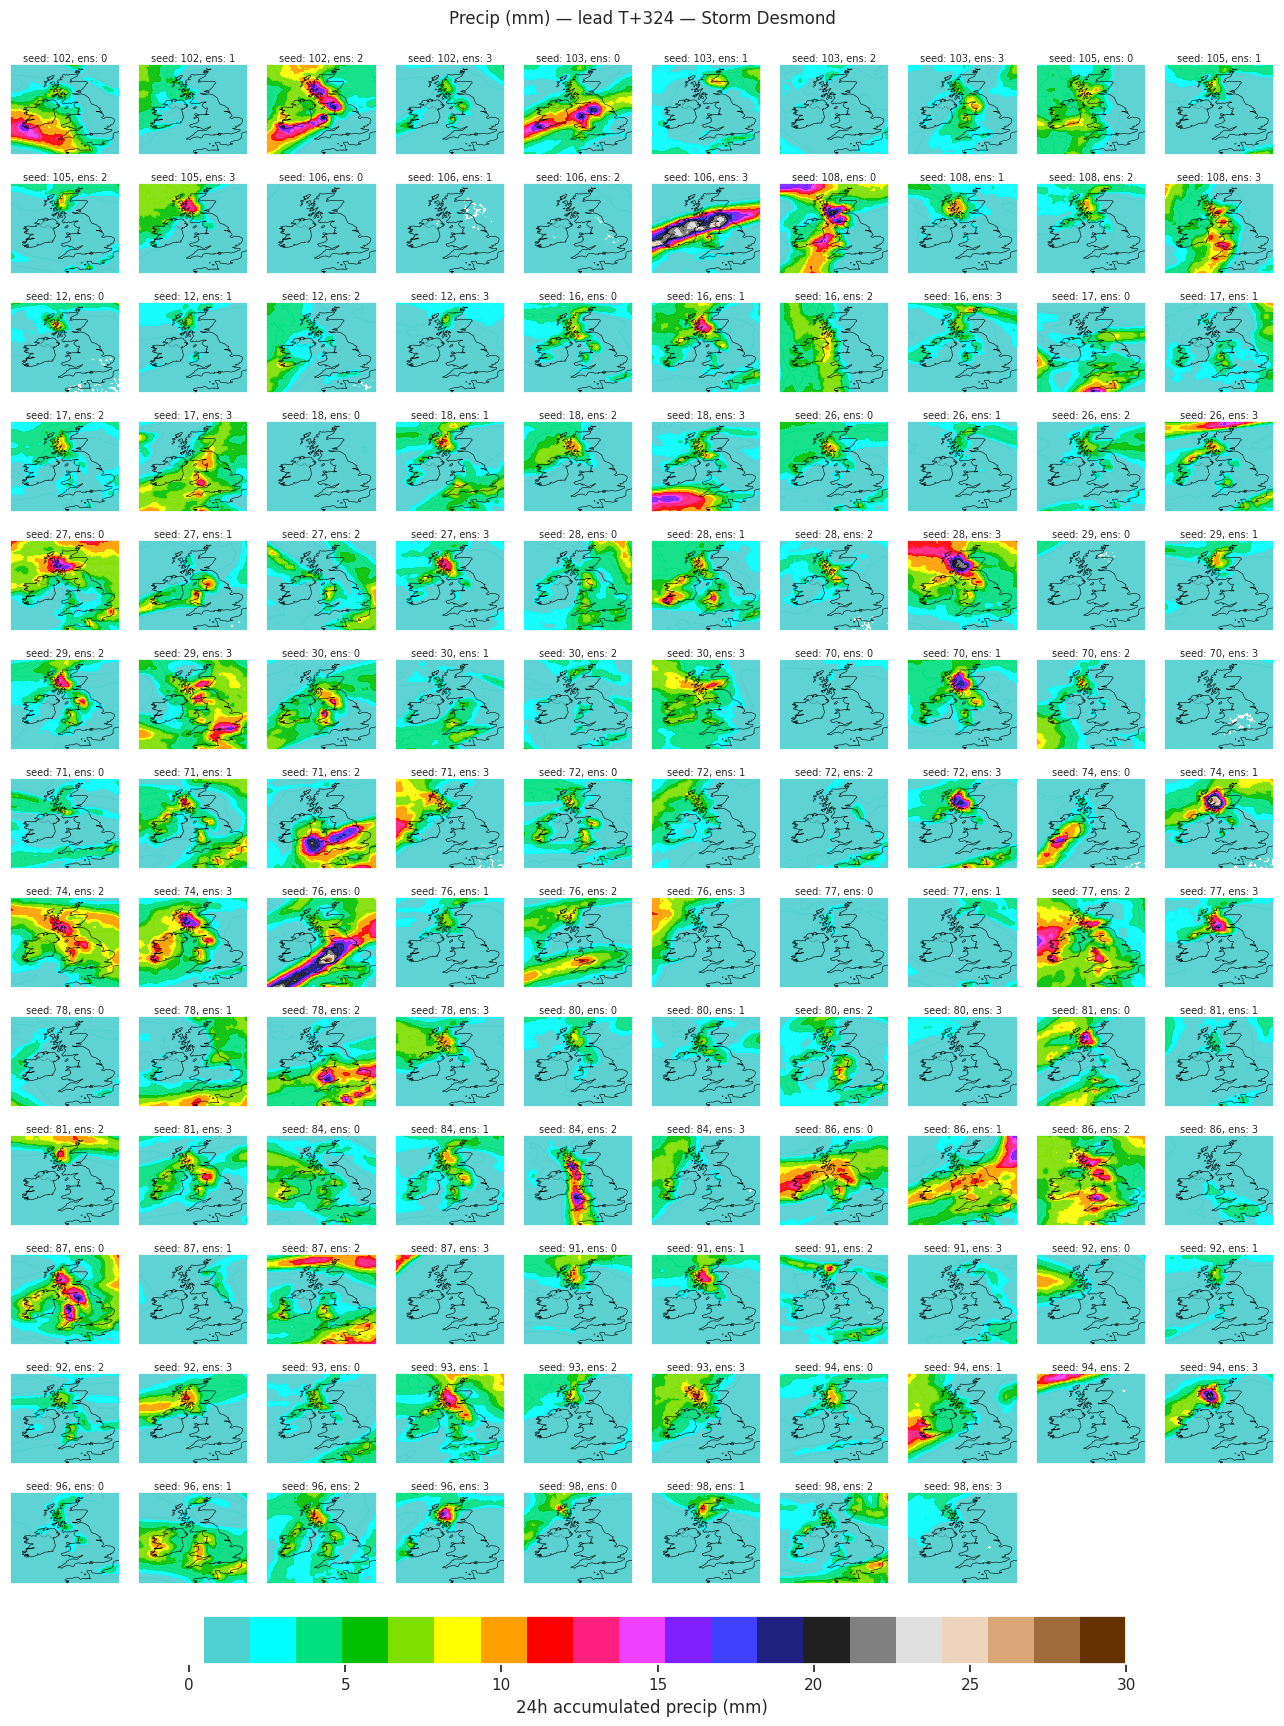

In [35]:
if rolling_window == 4:
    var = 'pr24'
    interval_str = '24h'
elif rolling_window == 1:
    var = 'pr06'
    interval_str = '6h'

# get ensemble coordinate values (labels)
n_ens = da_pr_roll.sizes['member']

# grid layout
nrows = math.ceil(n_ens / ncols)
fig_w = ncols * panel_size
fig_h = nrows * panel_size
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h),
                         subplot_kw={'projection': crs})
axes = np.asarray(axes).reshape(-1)  # flatten (works whether grid is 1D or 2D)

# compute common contour levels across all members for comparability
# use percentiles to avoid being dominated by outliers
#vmin = float(np.nanpercentile(da_all.values, 0.1))
#vmax = float(np.nanpercentile(da_all.values, 99.9))
if var == 'pr24' or var == 'pr06':
    vmin = np.min(da_pr_roll.values)
    vmax = np.max(da_pr_roll.values)
elif var == 'mslp':
    vmin = np.min(da_mslp_all.values)
    vmax = np.max(da_mslp_all.values)
interval = 1.0
lev_min = np.floor(vmin / interval) * interval
lev_max = np.ceil(vmax / interval) * interval
levels = np.arange(lev_min, lev_max + 1e-6, interval)

# iterate panels and plot each member
lon = da_pr_roll['lon'].values
lat = da_pr_roll['lat'].values
Lon, Lat = np.meshgrid(lon, lat)  # for contour plotting if desired

for i in range(n_ens):
    ax = axes[i]
    #ax.set_extent([-12.5, 6.5, 48.0, 60.0], crs=crs)  # adjust to desired UK+Ireland extent

    # plot coastlines/land
    ax.coastlines(resolution=coast_res, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS.with_scale(coast_res), linestyle=':', linewidth=0.3)
    ax.add_feature(cfeature.LAND.with_scale(coast_res), facecolor='lightgray', zorder=0)

    # plot either mslp or precip 
    if var == 'mslp':
        da_member = da_mslp_all.isel(member=i)  # select a single ensemble forecast to plot 

        # contour isobars; use thinner lines for small panels
        cs = ax.contour(lon, lat, da_member.values, levels=levels,
                        colors='k', linewidths=0.4, transform=crs)

    elif 'pr' in var:
        da_member = da_pr_roll.isel(member=i)
        cs = ax.contourf(lon, lat, da_member.values, levels=levels, 
                         cmap=cmap, transform=crs, alpha=0.9)

    # small title with ensemble id (keep font small)
    ax.set_title(labels[i], fontsize=7, pad=2)

    # remove tick labels for interior panels to keep things compact
    col = i % ncols
    row = i // ncols
    if col != 0:
        ax.set_yticklabels([])
        ax.set_yticks([])
    if row != (nrows - 1):
        ax.set_xticklabels([])
        ax.set_xticks([])

# turn off any unused axes (if ncols*nrows > n_ens)
for j in range(n_ens, len(axes)):
    axes[j].axis('off')

# overall suptitle and a shared legend/colorbar if desired
if var == 'mslp':
    plt.suptitle(f'MSLP (hPa) — lead T+{best_lead} — Storm {event_str}', fontsize=12, y=0.99)
elif 'pr' in var:
    plt.suptitle(f'Precip (mm) — lead T+{best_lead} — Storm {event_str}', fontsize=12, y=0.99)

# optional shared colorbar: create an invisible mappable with the contour levels
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=lev_min, vmax=lev_max)
sm = ScalarMappable(norm=norm, cmap=cmap)  # only used for colorbar scaling if you want
sm.set_array([])
plt.tight_layout()

# place horizontal colorbar below the figure
if 'pr' in var:
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal', fraction=0.03, pad=0.02)
    cbar.set_label(f'{interval_str} accumulated precip (mm)')

#out_file = f'/mnt/data/output_plots/{event_str}_{var}_postage_stamps_T{best_lead}.png'
#plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()

## Select SFNO forecasts that are most similar to ERA5

- Pick 4/5 forecasts and process these further 
- Develop a land-sea mask and concentrate on land points over the UK and Ireland
- Calculate the distribution of 24-h accumulated precipitation (+ mslp) for these forecasts 
- Compare the distribution with that from ERA5 

In [ ]:
era5_closest_fcsts = [(76, 0), (87, 0), (93, 1), (102, 2)]
most_extreme_fcsts = [(26, 3), (106, 3), (28, 3), (94, 1), (76, 0), (78, 0), (93, 2), (70, 1), (105, 1), (86, 1)]
most_extreme_leads = [240, 324, 282, 264, 246, 348, 240, 240, 240, 318]

# subset the full datasets to just the selected forecasts and lead times for easier plotting and analysis
da_mslp = da_mslp_all.sel({'member': most_extreme_fcsts,
                           'lead_time': most_extreme_leads})
da_pr = da_pr_all.sel({'member': most_extreme_fcsts,
                       'lead_time': most_extreme_leads})

## Develop a land-sea mask and select only land points from ERA5 and SFNO forecasts

- TODO: merge these functions by generalising the latitude + longitude selection code

In [ ]:
def sfno_land_sea_mask(da: xr.DataArray | xr.Dataset) -> xr.DataArray:
    """ 
    Develop a land-sea mask for SFNO forecasts using regionmask and Natural Earth land polygons. 
    This will allow us to exclude ocean points from our analysis, which is important for precipitation forecasts where we are primarily interested in impacts on land.
    """
    # extract latitude/longitude arrays 
    try:
        lon = da['lon'].values
    except Exception: 
        lon = da['longitude'].values

    try:
        lat = da['lat'].values
    except Exception:
        lat = da['latitude'].values

    # create an xarray 2D grid for regionmask
    lon2d, lat2d = np.meshgrid(lon, lat)

    # get Natural Earth "land" polygon(s) at your desired resolution
    # regionmask has several options; this uses natural_earth with "land_50"
    land = regionmask.defined_regions.natural_earth_v5_1_2.land_50

    # make a mask: result dims (lat, lon) with 1=land, 0=sea, -1 outside region if masked
    mask = land.mask(lon2d, lat2d)   # returns numpy array of region integer indices or -1 where not in region

    # boolean land mask
    land_bool = (mask == 0)  # if 'land' region index is 0; inspect mask.unique() if uncertain

    # convert to xarray DataArray
    try:
        land_mask_da = xr.DataArray(land_bool.astype(bool),
                                    coords={'lat': lat, 'lon': lon},
                                    dims=('lat', 'lon'))
    except Exception:
        land_mask_da = xr.DataArray(land_bool.astype(bool),
                                    coords={'latitude': lat, 'longitude': lon},
                                    dims=('latitude', 'longitude'))

    # apply to precip DataArray da (with dims including lat/lon)
    da_land = da.where(land_mask_da) # previously applied to 'da_pr' i.e. only 4 ensembles 
    return da_land


def era5_land_sea_mask(era5_da: xr.DataArray | xr.Dataset) -> xr.DataArray:
    """ 
    Develop a land-sea mask for ERA5 data using regionmask and Natural Earth land polygons. 
    This will allow us to exclude ocean points from our analysis, which is important for precipitation forecasts
    """
    # extract latitude/longitude arrays 
    try:
        lon = era5_da['lon'].values
    except Exception: 
        lon = era5_da['longitude'].values

    try:
        lat = era5_da['lat'].values
    except Exception:
        lat = era5_da['latitude'].values

    # create an xarray 2D grid for regionmask
    lon2d, lat2d = np.meshgrid(lon, lat)

    # get Natural Earth "land" polygon(s) at your desired resolution
    # regionmask has several options; this uses natural_earth with "land_50"
    land = regionmask.defined_regions.natural_earth_v5_1_2.land_50

    # make a mask: result dims (lat, lon) with 1=land, 0=sea, -1 outside region if masked
    mask = land.mask(lon2d, lat2d)   # returns numpy array of region integer indices or -1 where not in region

    # boolean land mask
    land_bool = (mask == 0)  # if 'land' region index is 0; inspect mask.unique() if uncertain

    # convert to xarray DataArray
    try:
        era5_land_mask_da = xr.DataArray(land_bool.astype(bool),
                                        coords={'latitude': lat, 'longitude': lon},
                                        dims=('latitude', 'longitude'))
    except Exception:
        era5_land_mask_da = xr.DataArray(land_bool.astype(bool),
                                        coords={'lat': lat, 'lon': lon},
                                        dims=('lat', 'lon'))

    # apply to precip DataArray da (with dims including lat/lon)
    era5_land = era5_da.where(era5_land_mask_da)
    return era5_land

## Design a CDF plot to plot the distribution of 24-h accumulated precip

- Subset to the UK and Ireland 
- For each ensemble forecast, flatten the values into a 1D array before plotting

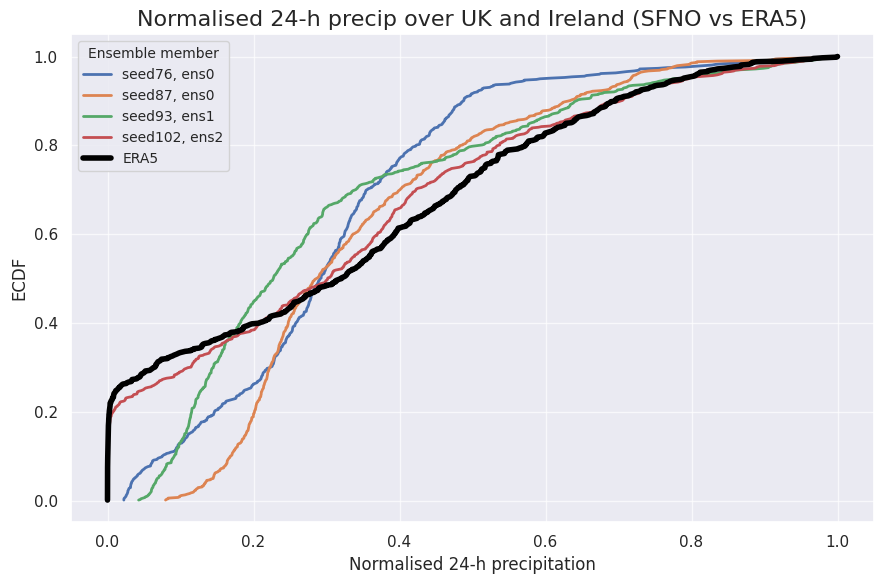

In [ ]:
uk_lat_bounds = [60, 50.25] # ERA5 only extends to 60N, so match that value 
uk_lon_bounds = [-11, 1.5]
var = 'pr24'

da_pr_land = sfno_land_sea_mask(da_pr)
da_mslp_land = sfno_land_sea_mask(da_mslp)
era5_pr_land = era5_land_sea_mask(era5_tp24)
era5_mslp_land = era5_land_sea_mask(era5_msl)

# subset to cover only UK and Ireland grid points 
if var == 'mslp':
    sfno_land = da_mslp_land.sel(lat=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
                                 lon=slice(uk_lon_bounds[0],uk_lon_bounds[1]))
    era5_land = era5_mslp_land.sel(latitude=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
                                   longitude=slice(uk_lon_bounds[0],uk_lon_bounds[1]))
else:
    sfno_land = da_pr_land.sel(lat=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
                               lon=slice(uk_lon_bounds[0],uk_lon_bounds[1]))
    era5_land = era5_pr_land.sel(latitude=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
                                 longitude=slice(uk_lon_bounds[0],uk_lon_bounds[1]))

# ensemble member labels 
labels = ['seed76, ens0', 'seed87, ens0', 'seed93, ens1', 'seed102, ens2']

# total number of forecasts 
num_ens = sfno_land.shape[2]

# loop over ensemble members and flatten ('ravel')
var_values_list = []
var_max_list = []
for m in range(0,4): # (0,4)
    var_values = sfno_land.isel(member=m).values.ravel()
    var_max = sfno_land.isel(member=m).max().values
    var_values = var_values[np.isfinite(var_values)]
    var_values = np.sort(var_values)
    var_values_list.append(var_values)
    var_max_list.append(var_max)

num_var = var_values_list[0].size
sfno_cdf = np.arange(1, num_var + 1) / num_var

# repeat pre-processing for ERA5 data 
era5_var_values = era5_land.values.ravel()
era5_var_values = era5_var_values[np.isfinite(era5_var_values)]
era5_var_values = np.sort(era5_var_values)

num_era5_var = era5_var_values.size
era5_cdf = np.arange(1, num_era5_var + 1) / num_era5_var

# normalise by setting a flag 
era5_var_max = era5_land.max().values
normalise = True
if normalise:
    for fcst in range(0,4):
        var_values_list[fcst] = var_values_list[fcst] / var_max_list[fcst]
    era5_var_values = era5_var_values / era5_var_max


fig, ax = plt.subplots(figsize=(9,6))

# plot ECDF
for m in range(0,4):
    ax.plot(var_values_list[m], sfno_cdf, lw=2, label=f'{labels[m]}')
if normalise:
    if var == 'mslp':
        ax.set_xlabel('Normalised mean sea level pressure')
        ax.set_title('Normalised mslp over UK and Ireland (SFNO vs ERA5)',fontsize=16)
    if var == 'pr06':
        ax.set_xlabel('Normalised 6-h precipitation')
        ax.set_title('Normalised 6-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
    elif var == 'pr24':
        ax.set_xlabel('Normalised 24-h precipitation')
        ax.set_title('Normalised 24-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
else:
    if var == 'mslp':
        ax.set_xlabel('Mean sea level pressure (hPa)')
        ax.set_title('Mslp over UK and Ireland (SFNO vs ERA5)',fontsize=16)
    elif var == 'pr06':
        ax.set_xlabel('6-h precipitation (mm)')
        ax.set_title('6-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
    elif var == 'pr24':
        ax.set_xlabel('24-h precipitation (mm)')
        ax.set_title('24-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
ax.plot(era5_var_values, era5_cdf, lw=4, color='black', label='ERA5')
ax.set_ylabel('ECDF')
ax.grid(alpha=0.7)
ax.legend(title='Ensemble member', fontsize='small', title_fontsize='small', loc='best')

plt.tight_layout()

if normalise:
    out_file = f'/mnt/data/output_plots/{event_str}_{var}_cdf_normalised.png'
else:
    out_file = f'/mnt/data/output_plots/{event_str}_{var}_cdf_unnormalised.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()

## Develop a method to match the distributions of SFNO and ERA5

- Use a `SciPy` interpolation method (`https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PchipInterpolator.html`) that preserves the distribution shape
- The quantile mapping functions that I originally thought I needed do not seem viable, because they require a time dimension (e.g. adjusting a climate model time series towards ERA5)
    - `https://python-cmethods.readthedocs.io/en/stable/methods.html`
    - `https://python-cmethods.readthedocs.io/en/stable/introduction.html`
    - `https://xclim.readthedocs.io/en/stable/notebooks/extendxclim.html`

In [11]:
import numpy as np
from scipy.interpolate import PchipInterpolator   # shape-preserving monotonic interpolator
import os

def quantile_map(sfno_vals,
                 era5_vals, 
                 n_quantiles=11, 
                 method='pchip'):
    """
    Quantile mapping of sfno_vals to era5_vals.
    Both inputs are 1D arrays (pooled).
    Returns mapped array (same shape as sfno_vals) and the mapping function.
    """
    # drop NaNs
    sfno = sfno_vals[np.isfinite(sfno_vals)]
    era5 = era5_vals[np.isfinite(era5_vals)]

    # sort values monotonically
    sfno = np.sort(sfno)
    era5 = np.sort(era5)

    qs = np.linspace(0, 1, n_quantiles)
    sfno_q = np.quantile(sfno, qs)
    era5_q = np.quantile(era5, qs)

    # ensure monotonic increasing (quantiles should be monotonic by construction)
    # build mapping function: from sf value -> era5 value
    # Use PCHIP for monotonic interpolation with sensible extrapolation
    if method == 'pchip':
        mapper = PchipInterpolator(sfno_q, era5_q, extrapolate=True)
    else:
        # numpy.interp fallback (linear; will clip at ends)
        def mapper(x):
            return np.interp(x, sfno_q, era5_q, left=era5_q[0], right=era5_q[-1])

    # apply mapping (preserve NaNs)
    mapped = np.full_like(sfno_vals, np.nan, dtype=float)
    mask = np.isfinite(sfno_vals)
    mapped[mask] = mapper(sfno_vals[mask])
    return mapped, mapper

## Troubleshooting

- Monday 16 February 2026 
- Help from ChatGPT
- Need to go back through the code to make sure I fully understand the functionality

In [12]:
import numpy as np
import xarray as xr
import os

def sanitize_and_write(ds_out, outpath, varname=None, compress=True, complvl=4):
    """
    Make ds_out safe for to_netcdf:
      - drop or convert object/tuple coords to strings
      - convert single-element numpy arrays in coords to Python scalars
      - convert array-like attrs to strings or scalars
      - cast data variables to float32 (optional)
    Then write ds_out to outpath with optional compression.
    """
    # make a copy to avoid mutating input
    ds = ds_out.copy()

    # --- clean coordinates ---
    for cname in list(ds.coords):
        val = ds.coords[cname].values
        # object dtype (likely tuple(s) or object arrays)
        if isinstance(val, np.ndarray) and val.dtype == object:
            if val.size == 1:
                # convert 0-d object array (e.g. tuple) to a safe string
                try:
                    scalar = val.item()
                    # if tuple/list, format nicely
                    if isinstance(scalar, (tuple, list)):
                        ds = ds.assign_coords({cname: str(tuple(int(x) if hasattr(x,'__int__') else x for x in scalar))})
                    else:
                        ds = ds.assign_coords({cname: str(scalar)})
                except Exception:
                    ds = ds.reset_coords(cname, drop=True)
            else:
                # multi-element object array -> drop it (can't safely write)
                ds = ds.reset_coords(cname, drop=True)

        # numeric 0-d arrays -> convert to python scalar value
        elif isinstance(val, np.ndarray) and val.size == 1:
            try:
                ds = ds.assign_coords({cname: val.item()})
            except Exception:
                # fallback to string
                ds = ds.assign_coords({cname: str(val.ravel()[0])})

        # if val is a numpy scalar (not ndarray)
        elif hasattr(val, 'dtype') and np.isscalar(val) and isinstance(val, (np.generic,)):
            try:
                ds = ds.assign_coords({cname: np.asscalar(val)})  # np.asscalar is deprecated, but assign_coords will accept python scalar
            except Exception:
                try:
                    ds = ds.assign_coords({cname: val.item()})
                except Exception:
                    ds = ds.assign_coords({cname: str(val)})

    # If you specifically want to remove the 'member' coord (common when writing per-member files):
    if 'member' in ds.coords:
        # either drop it:
        ds = ds.reset_coords('member', drop=True)
        # Or alternatively convert to a string label instead of dropping:
        # ds = ds.assign_coords(member=f"seed{seed:03d}_ens{ens}")

    # --- clean attributes ---
    for k, v in list(ds.attrs.items()):
        if isinstance(v, np.ndarray):
            if v.size == 1:
                ds.attrs[k] = v.item()
            else:
                ds.attrs[k] = str(v.tolist())
        elif isinstance(v, (list, tuple)):
            ds.attrs[k] = str(v)
        # else: leave scalar/string attrs as-is

    # --- ensure datavars are numeric (cast to float32 to match encoding)
    for var in ds.data_vars:
        try:
            ds[var] = ds[var].astype('float32')
        except Exception:
            pass

    # --- build encoding ---
    if varname is None:
        data_vars = list(ds.data_vars)
    else:
        data_vars = [varname] if varname in ds.data_vars else list(ds.data_vars)
    encoding = {}
    for v in data_vars:
        if compress:
            encoding[v] = {'zlib': True, 'complevel': complvl, 'dtype': 'float32'}
        else:
            encoding[v] = {'dtype': 'float32'}

    # write
    ds.to_netcdf(outpath, mode='w', format='NETCDF4', encoding=encoding)
    return outpath

# Example usage inside your loop:
out_dir = '/mnt/data/sfno/Desmond_adjusted/'
os.makedirs(out_dir, exist_ok=True)
out_labels = ['seed76_ens0', 'seed87_ens0', 'seed93_ens1', 'seed102_ens2']

for m in range(0,4):
    sfno = sfno_land.isel(member=m)
    sfno_vals_flat = sfno.values.ravel()
    era5_vals_flat = era5_land.values.ravel()
    mapped_vals, mapper = quantile_map(sfno_vals_flat, era5_vals_flat, n_quantiles=11)
    sfno_mapped = mapped_vals.reshape(sfno.shape)

    mapped_da = xr.DataArray(
        sfno_mapped,
        coords=sfno.coords,
        dims=sfno.dims,
        name='precip_adjusted',
        attrs=sfno.attrs
    )
    ds_out = mapped_da.to_dataset()

    fname = f"{event_str}_sfno_adjusted_{out_labels[m]}.nc"
    outpath = os.path.join(out_dir, fname)
    print("Writing:", outpath)

    sanitize_and_write(ds_out, outpath, varname='precip_adjusted')
    print("Wrote", outpath)

Writing: /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed76_ens0.nc
Wrote /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed76_ens0.nc
Writing: /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed87_ens0.nc
Wrote /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed87_ens0.nc
Writing: /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed93_ens1.nc
Wrote /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed93_ens1.nc
Writing: /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed102_ens2.nc
Wrote /mnt/data/sfno/Desmond_adjusted/Desmond_sfno_adjusted_seed102_ens2.nc


## Reproduce CDF plot with adjusted SFNO data

In [13]:
# uk_lat_bounds = [60, 50.25] # ERA5 only extends to 60N, so match that value 
# uk_lon_bounds = [-11, 1.5]
# var = 'pr24'

# # subset to cover only UK and Ireland grid points 
# if var == 'mslp':
#     sfno_land = da_mslp_land.sel(lat=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
#                                  lon=slice(uk_lon_bounds[0],uk_lon_bounds[1]))
#     era5_land = era5_mslp_land.sel(latitude=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
#                                    longitude=slice(uk_lon_bounds[0],uk_lon_bounds[1]))
# else:
#     sfno_land = da_pr_land.sel(lat=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
#                                lon=slice(uk_lon_bounds[0],uk_lon_bounds[1]))
#     era5_land = era5_pr_land.sel(latitude=slice(uk_lat_bounds[0],uk_lat_bounds[1]),
#                                  longitude=slice(uk_lon_bounds[0],uk_lon_bounds[1]))

# # ensemble member labels 
# labels = ['seed76_ens0', 'seed87_ens0', 'seed93_ens1', 'seed102_ens2']
# labels_adj = ['seed76_ens0_adj', 'seed87_ens0_adj', 'seed93_ens1_adj', 'seed102_ens2_adj']

# # loop over ensemble members and flatten ('ravel')
# var_values_list = []
# var_max_list = []
# for m in range(0,4):
#     var_values = sfno_land.isel(member=m).values.ravel()
#     var_max = sfno_land.isel(member=m).max().values
#     var_values = var_values[np.isfinite(var_values)]
#     var_values = np.sort(var_values)
#     var_values_list.append(var_values)
#     var_max_list.append(var_max)

# num_var = var_values_list[0].size
# cdf = np.arange(1, num_var + 1) / num_var

# # repeat pre-processing for ERA5 data 
# era5_var_values = era5_land.values.ravel()
# era5_var_values = era5_var_values[np.isfinite(era5_var_values)]
# era5_var_values = np.sort(era5_var_values)

# num_era5_var = era5_var_values.size
# era5_cdf = np.arange(1, num_era5_var + 1) / num_era5_var

# # # Also include adjusted SFNO time series 
# # sfno_mapped_values = sfno_mapped[np.isfinite(sfno_mapped)]
# # sfno_mapped_values = np.sort(sfno_mapped_values)

# # normalise by setting a flag 
# era5_var_max = era5_land.max().values
# #sfno_mapped_max = np.nanmax(sfno_mapped)
# normalise = True
# if normalise:
#     for fcst in range(0,4):
#         sfno_mapped_values = sfno_mapped_list[fcst].ravel()
#         sfno_mapped_values = sfno_mapped_values[np.isfinite(sfno_mapped_values)]
#         sfno_mapped_values = np.sort(sfno_mapped_values)
#         var_values_list[fcst] = var_values_list[fcst] / var_max_list[fcst]
#         #sfno_mapped_list[fcst] = sfno_mapped_list[fcst] / np.nanmax(sfno_mapped_list[fcst])
#         sfno_mapped_list[fcst] = sfno_mapped_values / np.nanmax(sfno_mapped_values)
#     era5_var_values = era5_var_values / era5_var_max
#     #sfno_mapped_values = sfno_mapped_values / sfno_mapped_max


# # pick 4 colors (tab10 has distinct colours; you can use any cmap or list)
# cmap = plt.get_cmap('tab10')
# colours = [cmap(i) for i in range(4)]

# fig, ax = plt.subplots(figsize=(9,6))

# # plot ECDF
# for m in range(0,4):
#     colour = colours[m % len(colours)]
#     ax.plot(var_values_list[m], cdf, lw=2, ls='--', alpha=0.5, color=colour, label=f'{labels[m]}')
#     ax.plot(sfno_mapped_list[m], cdf, lw=3, color=colour, label=f'{labels_adj[m]}')
# if normalise:
#     if var == 'mslp':
#         ax.set_xlabel('Normalised mean sea level pressure')
#         ax.set_title('Normalised mslp over UK and Ireland (SFNO vs ERA5)',fontsize=16)
#     if var == 'pr06':
#         ax.set_xlabel('Normalised 6-h precipitation')
#         ax.set_title('Normalised 6-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
#     elif var == 'pr24':
#         ax.set_xlabel('Normalised 24-h precipitation')
#         ax.set_title('Normalised 24-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
# else:
#     if var == 'mslp':
#         ax.set_xlabel('Mean sea level pressure (hPa)')
#         ax.set_title('Mslp over UK and Ireland (SFNO vs ERA5)',fontsize=16)
#     elif var == 'pr06':
#         ax.set_xlabel('6-h precipitation (mm)')
#         ax.set_title('6-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
#     elif var == 'pr24':
#         ax.set_xlabel('24-h precipitation (mm)')
#         ax.set_title('24-h precip over UK and Ireland (SFNO vs ERA5)',fontsize=16)
# ax.plot(era5_var_values, era5_cdf, lw=4, color='black', alpha=0.5, label='ERA5')
# ax.set_ylabel('ECDF')
# ax.grid(alpha=0.7)
# ax.legend(title='Ensemble member', fontsize='small', title_fontsize='small', loc='best')

# plt.tight_layout()

# if normalise:
#     out_file = f'/mnt/data/output_plots/{event_str}_{var}_cdf_normalised.png'
# else:
#     out_file = f'/mnt/data/output_plots/{event_str}_{var}_cdf_unnormalised.png'
# plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)
# plt.show()

## Compare the spatial fields before and after adjustment 

In [14]:
sfno_adjusted_path = [f'/mnt/data/sfno/Desmond_adjusted/{event_str}_sfno_adjusted_seed76_ens0.nc',
                 f'/mnt/data/sfno/Desmond_adjusted/{event_str}_sfno_adjusted_seed87_ens0.nc',
                 f'/mnt/data/sfno/Desmond_adjusted/{event_str}_sfno_adjusted_seed93_ens1.nc',
                 f'/mnt/data/sfno/Desmond_adjusted/{event_str}_sfno_adjusted_seed102_ens2.nc']

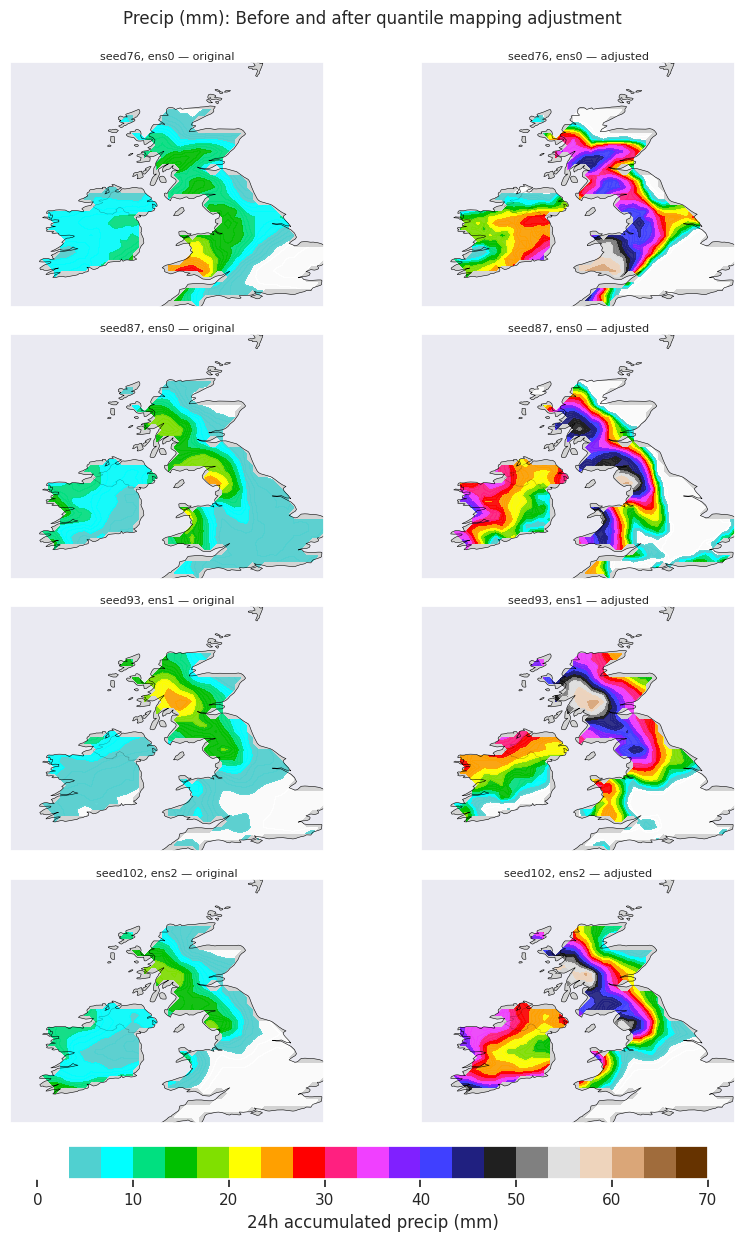

In [15]:
nrows, ncols = 4, 2 
num_ens = 4 # number of SFNO ensemble forecasts to plot 

fig, axes = plt.subplots(nrows, ncols, figsize=(9, 12),
                         subplot_kw={'projection': crs})

# compute common contour levels across all members for comparability
vmin = 0 
vmax = 70 
interval = 1.0
lev_min = np.floor(vmin / interval) * interval
lev_max = np.ceil(vmax / interval) * interval
levels = np.arange(lev_min, lev_max + 1e-6, interval)

# iterate panels and plot each member
lon = sfno_land['lon'].values
lat = sfno_land['lat'].values

for m in range(num_ens):
    row = m 
    axL = axes[row, 0]
    axR = axes[row, 1]

    # add coastlines + borders to both panels 
    for ax in (axL, axR):
        ax.coastlines(resolution=coast_res, linewidth=0.4)
        ax.add_feature(cfeature.BORDERS.with_scale(coast_res), linestyle=':', linewidth=0.3)
        ax.add_feature(cfeature.LAND.with_scale(coast_res), facecolor='lightgray', zorder=0)

    # get the data and plot 
    sfno_orig = sfno_land.isel(member=m)
    sfno_adj = xr.open_dataset(sfno_adjusted_path[m])['precip_adjusted']
    #sfno_adj = sfno_mapped_da_list[m]

    csL = axL.contourf(lon, lat, sfno_orig.values, levels=levels, 
                       cmap=cmap, transform=crs, alpha=0.9)
    csR = axR.contourf(lon, lat, sfno_adj.values, levels=levels,
                       cmap=cmap, transform=crs, alpha=0.9)

    # small title with ensemble id (keep font small)
    axL.set_title(f'{labels[m]} — original', fontsize=8, pad=2)
    axR.set_title(f'{labels[m]} — adjusted', fontsize=8, pad=2)

    # Ticks: keep y ticks only on leftmost column and x ticks only on bottom row
    if row != (nrows - 1):
        axL.set_xticks([])
        axR.set_xticks([])
    if 0 != 0:  # placeholder if you ever want to hide left y ticks for interior columns; here left col keeps y ticks
        axL.set_yticks([])
    # optionally remove y ticks for the right column
    axR.set_yticks([])

# turn off any unused axes (if any)
total_axes = nrows * ncols
for idx in range(n_ens * 2, total_axes):
    r = idx // ncols
    c = idx % ncols
    axes[r, c].axis('off')

# shared colourbar and plot title 
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=lev_min, vmax=lev_max)
sm = ScalarMappable(norm=norm, cmap=cmap)  # only used for colorbar scaling if you want
sm.set_array([])
plt.suptitle(f'Precip (mm): Before and after quantile mapping adjustment', fontsize=12, y=0.99)
plt.tight_layout()

# place horizontal colorbar below the figure
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.03, pad=0.02)
cbar.set_label(f'{interval_str} accumulated precip (mm)')

out_file = f'/mnt/data/output_plots/{event_str}_{var}_quantile_mapping_adjustment.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()